<a href="https://colab.research.google.com/github/Sibitenda/BAchelors_CS/blob/main/Artificial%20Intelligence/week3_knowledge/Week3_KR_Practicals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 Practical: Knowledge Representation & Reasoning

This notebook covers hands-on exercises for:
1. **Rule-Based Expert Systems** (using Python IF–THEN rules)
2. **Semantic Networks** (using NetworkX for visualization)
3. **Predicate Logic Reasoning** (using pyDatalog for inference)

---

## Learning Objectives
- Understand how to represent knowledge using rules, graphs, and logic.
- Implement a simple rule-based expert system in Python.
- Build and visualize semantic networks for conceptual domains.
- Use predicate logic (via `pyDatalog`) to make logical inferences.

---


## 1. Rule-Based Expert System

1. Rule-Based Expert Systems


Example Use:

Convert dataset info into IF–THEN rules:

If fever AND cough → Flu

If buying=high AND safety=low → Reject car

This makes the rule-based advisor data-driven instead of just hand-crafted.



In this task, we simulate a **simple medical advisor** that uses IF–THEN rules.

### Example Code


In [1]:
# Simple rule-based medical expert system

# Define rules as conditions and outcomes
rules = {
    "fever AND cough": "Flu",
    "headache AND nausea": "Migraine",
    "chest pain AND shortness of breath": "Heart Disease"
}

# Example patient symptoms
symptoms = ["fever", "cough"]

# Inference engine: forward chaining
for rule, disease in rules.items():
    conditions = rule.split(" AND ")
    if all(symptom in symptoms for symptom in conditions):
        print(f"Diagnosis: {disease}")


Diagnosis: Flu


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhivyeshrk/diseases-and-symptoms-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diseases-and-symptoms-dataset' dataset.
Path to dataset files: /kaggle/input/diseases-and-symptoms-dataset


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sibitendaharriet","key":"12fdc7b1d6850701695e662afc227219"}'}

In [8]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/   # upload kaggle.json from your Kaggle account
!chmod 600 ~/.kaggle/kaggle.json


In [10]:
!kaggle datasets download -d dhivyeshrk/diseases-and-symptoms-dataset
!unzip diseases-and-symptoms-dataset.zip -d dataset


Dataset URL: https://www.kaggle.com/datasets/dhivyeshrk/diseases-and-symptoms-dataset
License(s): world-bank
diseases-and-symptoms-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  diseases-and-symptoms-dataset.zip
replace dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [11]:
import pandas as pd
import os

print(os.listdir("dataset"))

# Example (adjust if filename differs)
df = pd.read_csv("dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv")
print(df.head())


['Final_Augmented_dataset_Diseases_and_Symptoms.csv']
         diseases  anxiety and nervousness  depression  shortness of breath  \
0  panic disorder                        1           0                    1   
1  panic disorder                        0           0                    1   
2  panic disorder                        1           1                    1   
3  panic disorder                        1           0                    0   
4  panic disorder                        1           1                    0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                                 1                 0          0         0   
1                                 1                 0          1         1   
2                                 1                 0          1         1   
3                                 1                 0          1         1   
4                                 0                 0          0         1   

  

In [12]:
import pandas as pd

df = pd.read_csv("dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv")

# Example hardcoded rules
def symptom_to_disease_rule(row):
    if row["shortness of breath"] == 1 and row["chest tightness"] == 1:
        return "Asthma"
    elif row["anxiety and nervousness"] == 1 and row["insomnia"] == 1:
        return "panic disorder"
    else:
        return "Unknown"

df["Predicted_Disease"] = df.apply(symptom_to_disease_rule, axis=1)

print(df[["diseases", "Predicted_Disease"]].head())


         diseases Predicted_Disease
0  panic disorder            Asthma
1  panic disorder           Unknown
2  panic disorder    panic disorder
3  panic disorder    panic disorder
4  panic disorder    panic disorder


In [13]:
print(df[["diseases", "Predicted_Disease"]].head(20))

          diseases Predicted_Disease
0   panic disorder            Asthma
1   panic disorder           Unknown
2   panic disorder    panic disorder
3   panic disorder    panic disorder
4   panic disorder    panic disorder
5   panic disorder           Unknown
6   panic disorder           Unknown
7   panic disorder           Unknown
8   panic disorder    panic disorder
9   panic disorder           Unknown
10  panic disorder           Unknown
11  panic disorder           Unknown
12  panic disorder            Asthma
13  panic disorder           Unknown
14  panic disorder    panic disorder
15  panic disorder           Unknown
16  panic disorder            Asthma
17  panic disorder            Asthma
18  panic disorder           Unknown
19  panic disorder           Unknown


In [14]:
import pandas as pd
import seaborn as sns

# Load Titanic dataset
df = sns.load_dataset("titanic")
# print(df.head())

# Simple rules based on columns
def survival_rule(row):
    if row["sex"] == "female":
        return 1  # survived
    elif row["pclass"] == 1 and pd.notnull(row["age"]) and row["age"] < 18:
        return 1
    else:
        return 0

df["Predicted_Survival"] = df.apply(survival_rule, axis=1)
print(df[["sex", "pclass", "age", "Predicted_Survival"]].head())


      sex  pclass   age  Predicted_Survival
0    male       3  22.0                   0
1  female       1  38.0                   1
2  female       3  26.0                   1
3  female       1  35.0                   1
4    male       3  35.0                   0


In [16]:
import pandas as pd
from google.colab import files
files.upload()
# Load dataset
col_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df = pd.read_csv("car.data", names=col_names)
print(df.head())

# Rule-based evaluation (using buying + safety only)
def car_decision(row):
    if row["buying"] == "high" and row["safety"] == "low":
        return "Reject"
    elif row["buying"] == "low" and row["safety"] == "high":
        return "Accept"
    else:
        return "Consider"

df["Decision"] = df.apply(car_decision, axis=1)
print(df[["buying", "safety", "Decision"]].head())


Saving car.data to car.data
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
  buying safety  Decision
0  vhigh    low  Consider
1  vhigh    med  Consider
2  vhigh   high  Consider
3  vhigh    low  Consider
4  vhigh    med  Consider


## 2. Semantic Networks

We use **graph structures** to represent knowledge in domains.

### Example: Animal Taxonomy Network


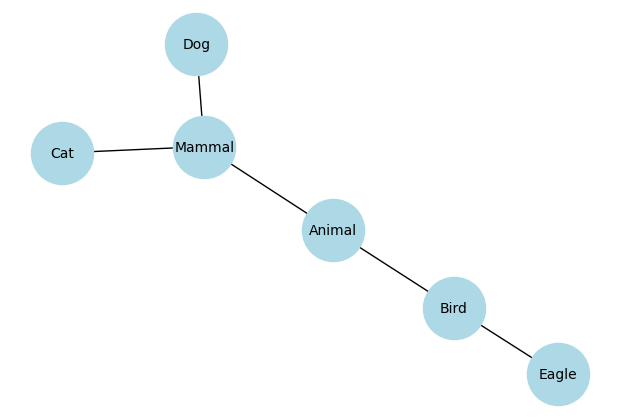

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a semantic network (graph)
G = nx.Graph()
G.add_edges_from([
    ("Dog", "Mammal"),
    ("Cat", "Mammal"),
    ("Eagle", "Bird"),
    ("Mammal", "Animal"),
    ("Bird", "Animal")
])

# Draw the network
plt.figure(figsize=(6,4))
nx.draw(G, with_labels=True, node_color="lightblue", node_size=2000, font_size=10)
plt.show()


Saving zoo.data to zoo.data
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   type  
0     1  
1     1  
2     4  


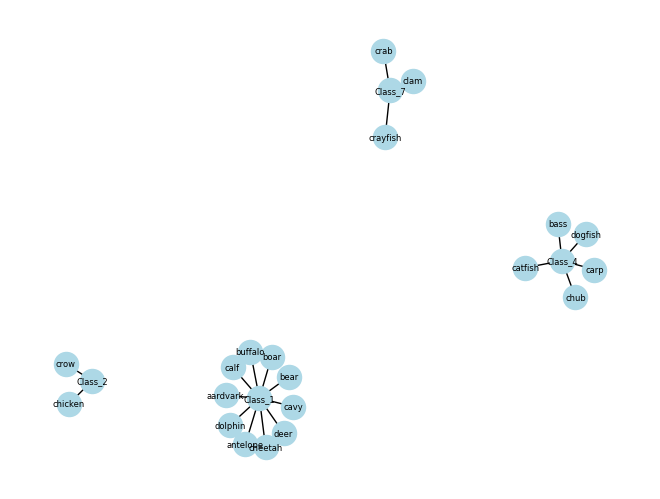

In [19]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from google.colab import files
files.upload()
# Load dataset
col_names = ["animal_name","hair","feathers","eggs","milk","airborne","aquatic",
             "predator","toothed","backbone","breathes","venomous","fins","legs",
             "tail","domestic","catsize","type"]
df = pd.read_csv("zoo.data", names=col_names)
print(df.head())
df1=df.head(20)
# Build semantic network (animal → class type)
G = nx.Graph()
for _, row in df1.iterrows():
    G.add_edge(row["animal_name"], f"Class_{row['type']}")

nx.draw(G, with_labels=True, node_color="lightblue", font_size=6)
plt.show()


Dataset URL: https://www.kaggle.com/datasets/thedevastator/dbpedia-ontology-dataset
License(s): CC0-1.0
  0% 0.00/66.3M [00:00<?, ?B/s]
100% 66.3M/66.3M [00:00<00:00, 1.17GB/s]
   label                              title  \
0      0                   E. D. Abbott Ltd   
1      0                     Schwan-Stabilo   
2      0                         Q-workshop   
3      0  Marvell Software Solutions Israel   
4      0        Bergan Mercy Medical Center   

                                             content  
0   Abbott of Farnham E D Abbott Limited was a Br...  
1   Schwan-STABILO is a German maker of pens for ...  
2   Q-workshop is a Polish company located in Poz...  
3   Marvell Software Solutions Israel known as RA...  
4   Bergan Mercy Medical Center is a hospital loc...  
Index(['label', 'title', 'content'], dtype='object')
                              Entity    Target Relation
0                   E. D. Abbott Ltd     Other     is_a
1                     Schwan-Stabilo     Othe

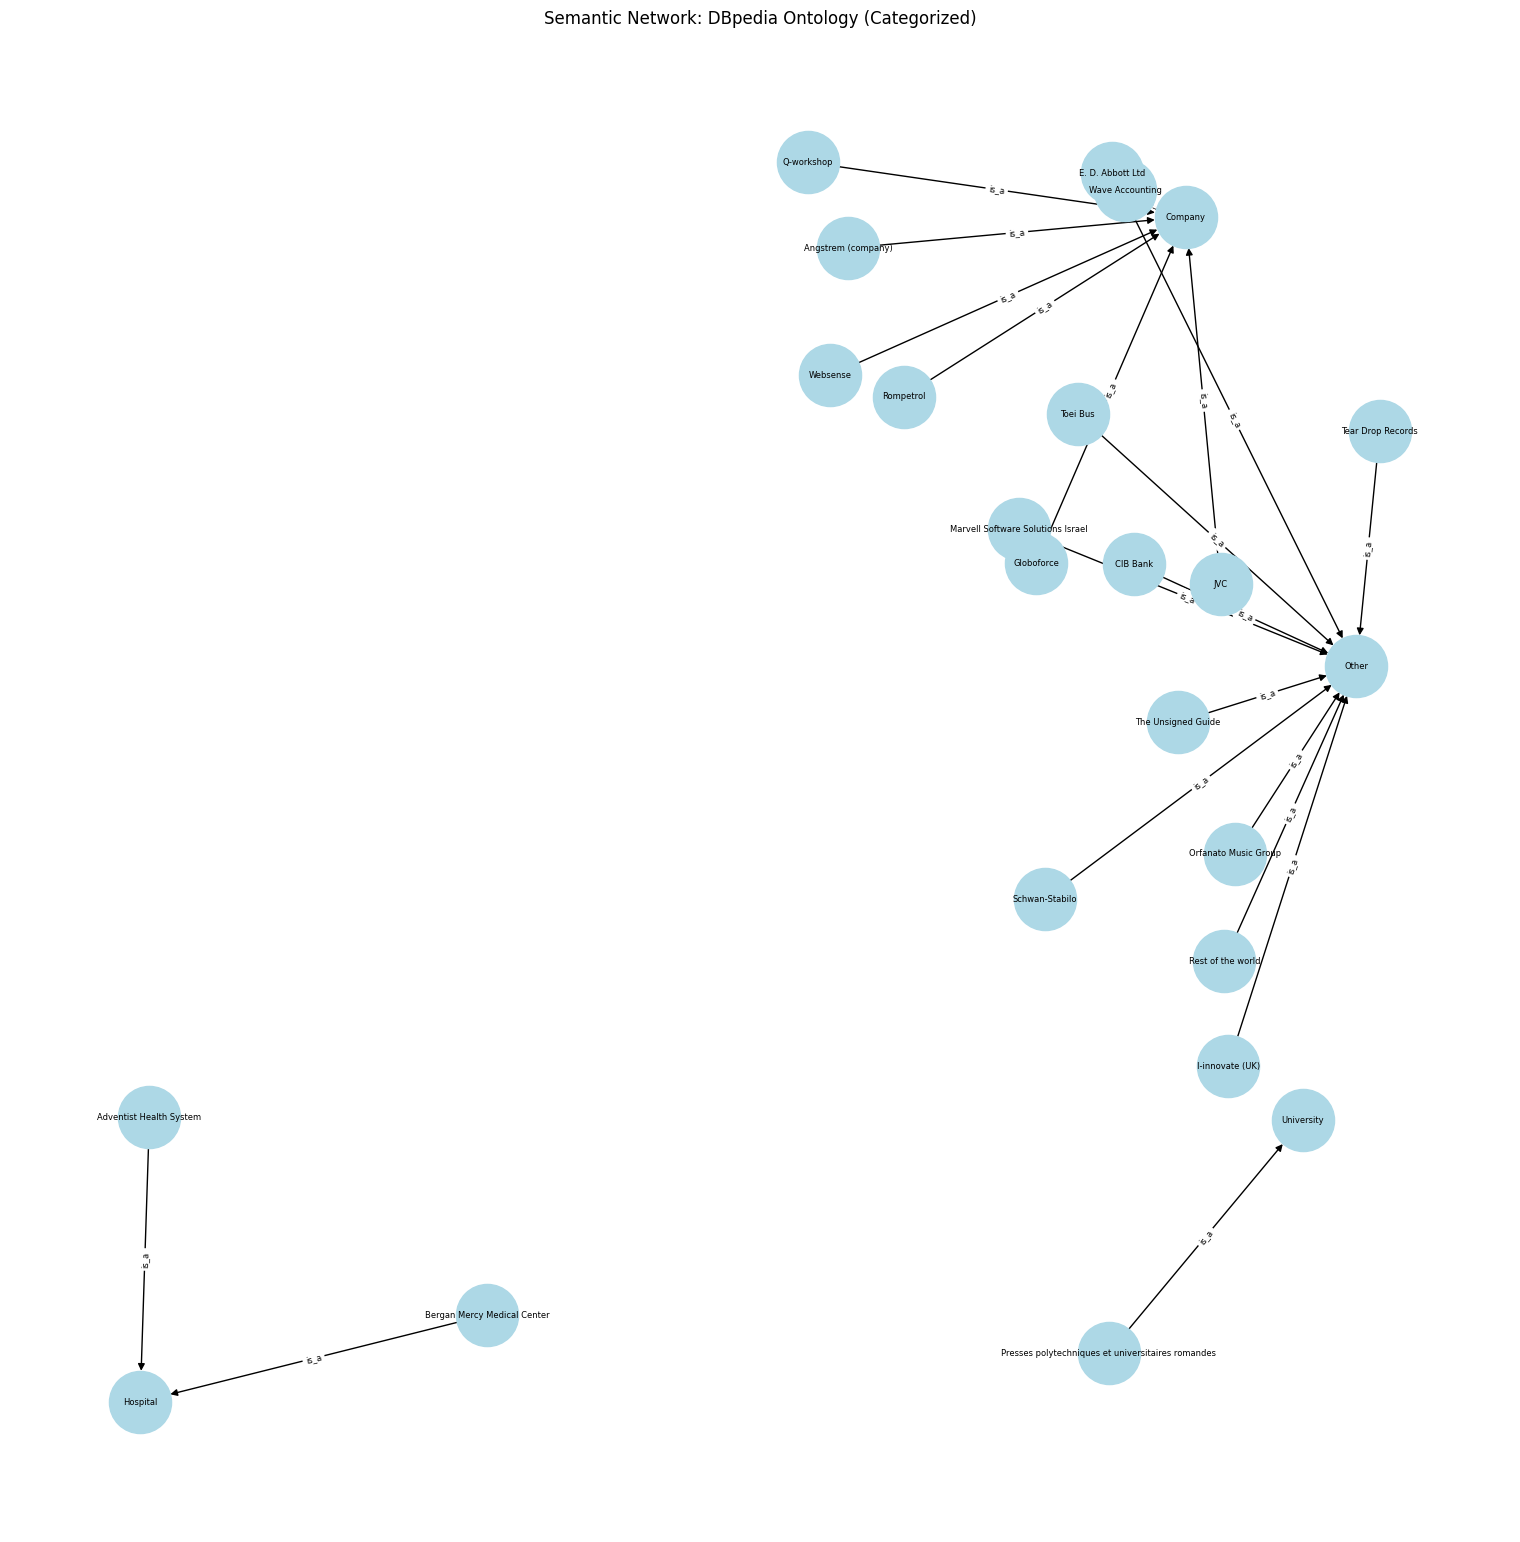

In [21]:
# # Step 0: Install required packages
!pip install -q kaggle networkx matplotlib pandas

# Step 1: Upload kaggle.json for API access
# Make sure you've uploaded kaggle.json to Colab environment
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 2: Download the DBpedia Ontology dataset from Kaggle
!kaggle datasets download -d thedevastator/dbpedia-ontology-dataset -p dataset --unzip

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the CSV
df2 = pd.read_csv("dataset/train.csv")  # or test.csv
df=df2.head(20)
print(df.head())
print(df.columns)

# Example: extract "industry" or "type" from content using a simple rule
edges = []
for _, row in df.iterrows():
    entity = row['title']
    # Simple rule: if content contains "hospital", "company", etc.
    content = str(row['content']).lower()
    if "hospital" in content:
        target = "Hospital"
    elif "company" in content or "corporation" in content:
        target = "Company"
    elif "university" in content:
        target = "University"
    else:
        target = "Other"
    edges.append((entity, target, "is_a"))

df_edges = pd.DataFrame(edges, columns=['Entity', 'Target', 'Relation'])
print(df_edges.head())

# Build the graph
G = nx.DiGraph()
for _, row in df_edges.iterrows():
    G.add_edge(row['Entity'], row['Target'], relation=row['Relation'])

# Visualize
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G, k=0.5, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue", font_size=6)
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.title("Semantic Network: DBpedia Ontology (Categorized)")
plt.show()


                           diseases  anxiety and nervousness  depression  \
246895  conjunctivitis due to virus                        0           0   
246896  conjunctivitis due to virus                        0           0   
246897  conjunctivitis due to virus                        0           0   
246898  conjunctivitis due to virus                        0           0   
246899  conjunctivitis due to virus                        0           0   

        shortness of breath  depressive or psychotic symptoms  \
246895                    0                                 0   
246896                    0                                 0   
246897                    0                                 0   
246898                    0                                 0   
246899                    0                                 0   

        sharp chest pain  dizziness  insomnia  abnormal involuntary movements  \
246895                 0          0         0                          

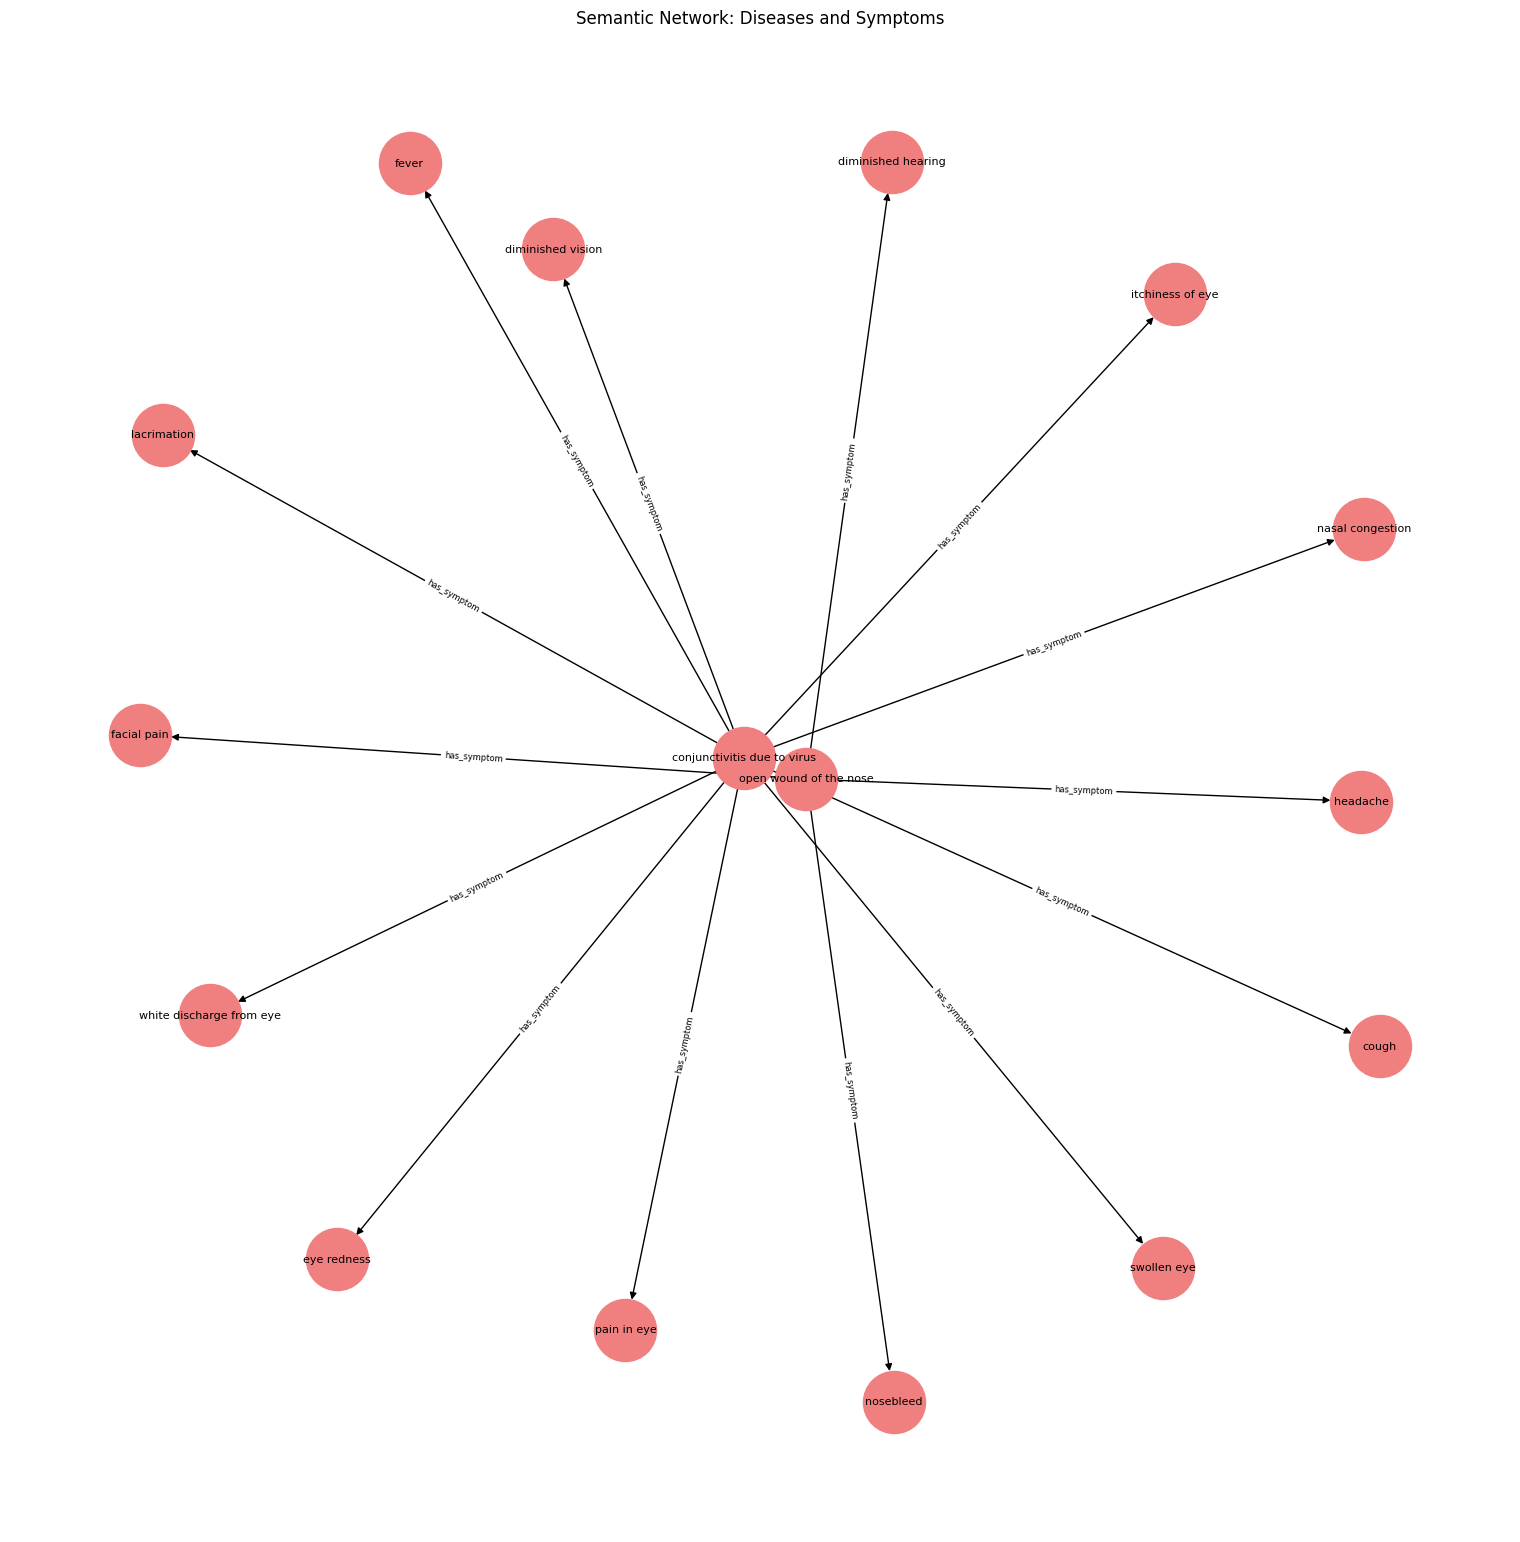

In [22]:
import pandas as pd
data_path = "dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
df2 = pd.read_csv(data_path)
df=df2.tail(50)
# Display first few rows
print(df.head())
print(df.columns)

# Step 5: Prepare the dataset for semantic network
# We'll take 'diseases' as Entity and all symptoms as Target if symptom = 1
# Create a long-format dataframe with Entity, Relation, Target

symptom_cols = df.columns[1:]  # all columns except 'diseases'
edges = []

for _, row in df.iterrows():
    entity = row['diseases']
    for symptom in symptom_cols:
        if row[symptom] == 1:
            edges.append((entity, 'has_symptom', symptom))

# Convert to DataFrame
df_edges = pd.DataFrame(edges, columns=['Entity', 'Relation', 'Target'])
print(df_edges.head())

# Step 6: Create and visualize the Semantic Network
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for _, row in df_edges.iterrows():
    G.add_edge(row['Entity'], row['Target'], relation=row['Relation'])

# Draw the network
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G, k=0.5, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightcoral", font_size=8)
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.title("Semantic Network: Diseases and Symptoms")
plt.show()


## 3. Predicate Logic Reasoning with pyDatalog

We use the `pyDatalog` library to represent and infer logical relationships.

### Example: Socrates is Mortal


In [23]:
!pip install pyDatalog

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.5/325.5 kB 8.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pyDatalog: filename=pydatalog-0.17.4-py2.py3-none-any.whl size=74278 sha256=1f7d50111db2f25224480fe8d61725ae72723c8922e34a79261bacf53265639a
  Stored in directory: /root/.cache/pip/wheels/3d/86/49/61fd7f650165a5795f4b61720e1aeb2875f7e3f6d09de485be
Successfully built pyDatalog


In [24]:
from pyDatalog import pyDatalog

# Define terms
pyDatalog.create_terms('X, Y, mortal, human')

# Facts
+ human('Socrates')
+ human('Plato')

# Rules
mortal(X) <= human(X)

# Query
print(mortal(X))


X       
--------
Plato   
Socrates


---
## Next Steps
- Extend the expert system with more rules (e.g., cold, allergy, diabetes).  
- Build a semantic network for a different domain (e.g., university: Student → Course → Faculty).  
- Add more predicates and rules in pyDatalog (e.g., parent, ancestor).  

By the end of this lab, you will have implemented three classical AI knowledge representation techniques.
